# Generalization Experiments

Generalization Gap: difference between training and test accuracy 

In [3]:
# Cell 1: Imports and Data Loading
import pandas as pd
import matplotlib.pyplot as plt

import seaborn as sns
import json
import numpy as np

# Load the datasets
best_per_dataset = pd.read_csv('../processed_results/best_per_dataset.csv')
best_avg = pd.read_csv('../processed_results/best_avg.csv')
results_hp = pd.read_csv('../results_with_hyperparameters.csv')

# Set aesthetic style
sns.set_theme(style="whitegrid")
%matplotlib inline

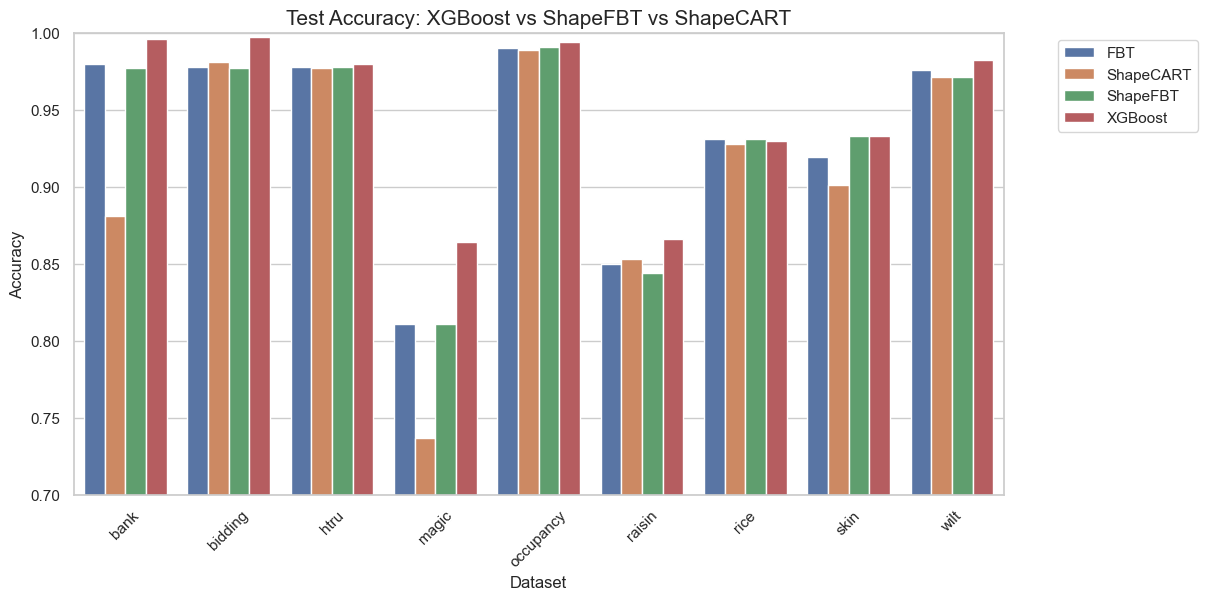

In [4]:
# Cell 2: Test Accuracy Comparison per Dataset
excluded_datasets = {'avila', 'bean', 'eye-state', 'fault', 'page', 'room', 'segment'}
filtered_best_per_dataset = best_per_dataset[
    ~best_per_dataset['dataset'].str.lower().isin(excluded_datasets)
]

plt.figure(figsize=(12, 6))
sns.barplot(data=filtered_best_per_dataset, x='dataset', y='test_acc', hue='model')
plt.title('Test Accuracy: XGBoost vs ShapeFBT vs ShapeCART', fontsize=15)
plt.ylabel('Accuracy')
plt.xlabel('Dataset')
plt.ylim(0.7, 1.0) # Adjusted to zoom in on the differences
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45)
plt.show()

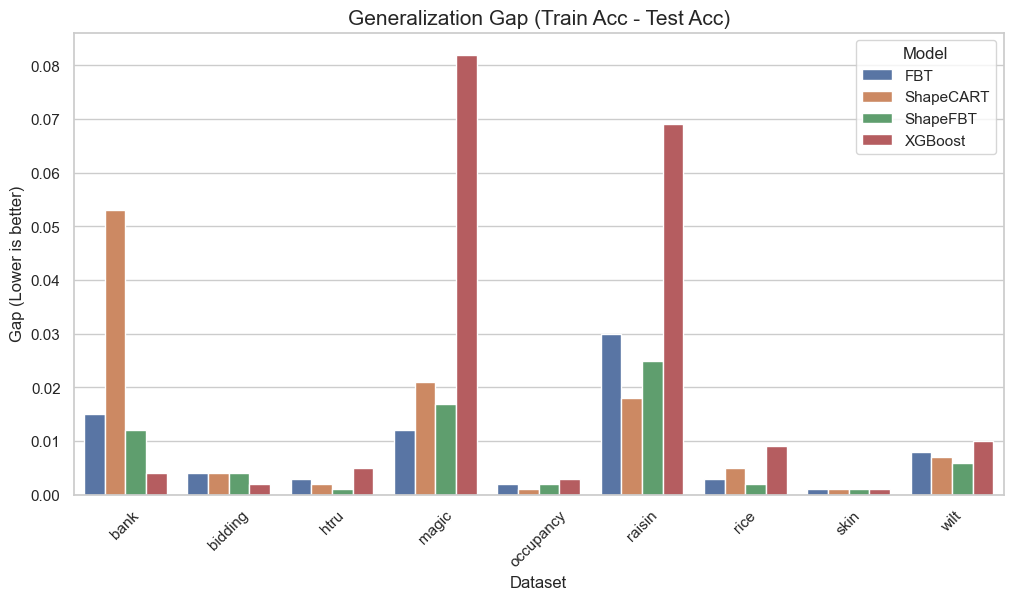

In [5]:
# Cell 3: Generalization Gap Analysis
# (Lower is better - indicates less overfitting)
plt.figure(figsize=(12, 6))
sns.barplot(data=filtered_best_per_dataset, x='dataset', y='generalization_gap', hue='model')
plt.title('Generalization Gap (Train Acc - Test Acc)', fontsize=15)
plt.ylabel('Gap (Lower is better)')
plt.xlabel('Dataset')
plt.legend(title='Model')
plt.xticks(rotation=45)
plt.show()

In [6]:
# New cell: Dataframe for visuals in Cell 2 and Cell 3
visual_cols = ['dataset', 'model', 'train_acc', 'test_acc', 'generalization_gap']
df_visuals = (
    filtered_best_per_dataset[visual_cols]
    .copy()
    .sort_values(['dataset', 'model'])
    .reset_index(drop=True)
)

# Display the full dataframe
# with pd.option_context('display.max_rows', None, 'display.max_columns', None):
#     display(df_visuals)

df_visuals

,dataset,model,train_acc,test_acc,generalization_gap
0,bank,FBT,0.996,0.980,0.015
1,bank,ShapeCART,0.934,0.881,0.053
2,bank,ShapeFBT,0.990,0.977,0.012
3,bank,XGBoost,1.000,0.996,0.004
4,bidding,FBT,0.980,0.978,0.004
5,bidding,ShapeCART,0.982,0.981,0.004
6,bidding,ShapeFBT,0.981,0.977,0.004
7,bidding,XGBoost,0.999,0.997,0.002
8,htru,FBT,0.981,0.978,0.003
9,htru,ShapeCART,0.979,0.977,0.002


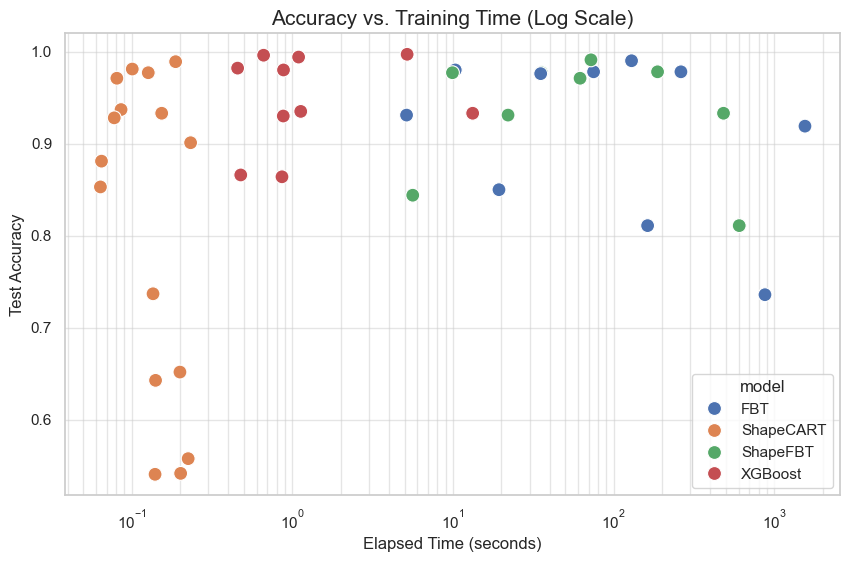

In [7]:
# Cell 4: Performance vs. Training Time (Log Scale)
plt.figure(figsize=(10, 6))
sns.scatterplot(data=best_per_dataset, x='elapsed_time', y='test_acc', hue='model', s=100)
plt.xscale('log')
plt.title('Accuracy vs. Training Time (Log Scale)', fontsize=15)
plt.xlabel('Elapsed Time (seconds)')
plt.ylabel('Test Accuracy')
plt.grid(True, which="both", ls="-", alpha=0.5)
plt.show()

In [8]:
# Cell 5: Hyperparameter Analysis (All Points Visible)
plt.figure(figsize=(12, 7))

# 1. Draw the boxplot (the "summary")
# We set outlier_shape='' to hide the default outlier diamonds 
# so they don't double-count with our circles.
sns.boxplot(
    data=shape_full.dropna(subset=['test_acc']), 
    x='outer_tree_max_depth', 
    y='test_acc',
    color='white',
    showfliers=False
)

# 2. Draw the "circles" (the individual trials)
# Using 'hue' here will color the circles by dataset, 
# which explains why some are high and some are low.
sns.stripplot(
    data=shape_full.dropna(subset=['test_acc']), 
    x='outer_tree_max_depth', 
    y='test_acc', 
    hue='dataset',
    jitter=True, 
    alpha=0.5, 
    dodge=True,  # This aligns circles with the dataset legend
    size=4
)

plt.title('ShapeFBT Accuracy: Full Distribution of Trials', fontsize=15)
plt.xlabel('Outer Tree Max Depth')
plt.ylabel('Test Accuracy')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title="Datasets")
plt.tight_layout()
plt.show()

NameError: name 'shape_full' is not defined

<Figure size 1200x700 with 0 Axes>

/var/folders/f2/g658svqn1s7ff_f07dxlbl480000gn/T/ipykernel_45983/3489260211.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=recovered_df, x='dataset', y='recovered_accuracy', palette='viridis')


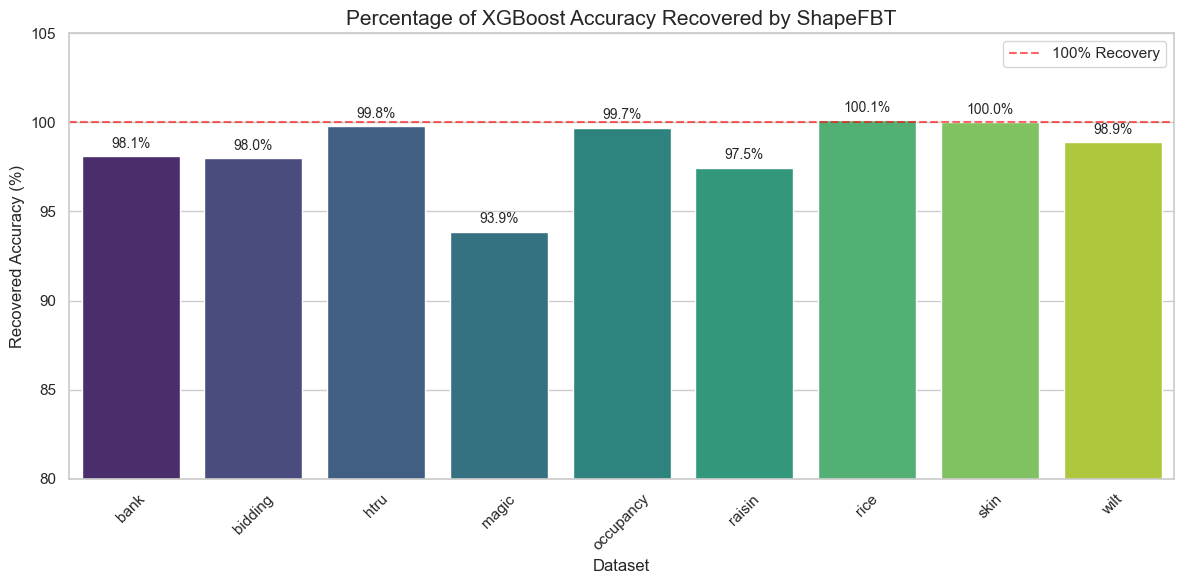

In [9]:
# Cell 6: Calculate and Plot Recovered Accuracy
# We define "Recovered Accuracy" as ShapeFBT_Test_Acc / XGBoost_Test_Acc

# 1. Prepare the data
xgb_best = best_per_dataset[best_per_dataset['model'] == 'XGBoost'][['dataset', 'test_acc']].rename(columns={'test_acc': 'xgb_acc'})
shape_best = best_per_dataset[best_per_dataset['model'] == 'ShapeFBT'][['dataset', 'test_acc']].rename(columns={'test_acc': 'shape_acc'})

# Merge and calculate ratio
recovered_df = pd.merge(xgb_best, shape_best, on='dataset').dropna()
recovered_df['recovered_accuracy'] = (recovered_df['shape_acc'] / recovered_df['xgb_acc']) * 100

# 2. Plotting
plt.figure(figsize=(12, 6))
ax = sns.barplot(data=recovered_df, x='dataset', y='recovered_accuracy', palette='viridis')

# Add a reference line at 100% (Full Recovery)
plt.axhline(100, ls='--', color='red', alpha=0.6, label='100% Recovery')

# Annotate bars with the percentage value
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha = 'center', va = 'center', 
                xytext = (0, 9), 
                textcoords = 'offset points',
                fontsize=10)

plt.title('Percentage of XGBoost Accuracy Recovered by ShapeFBT', fontsize=15)
plt.ylabel('Recovered Accuracy (%)')
plt.xlabel('Dataset')
plt.ylim(80, 105) # Focused on the 80-100% range
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

In [12]:
# Cell 7: Depth-wise averages for SagiFBT, ShapeFBT, ShapeCART/SGT

# Keep only the requested model families
models_depth = ['FBT', 'ShapeFBT', 'ShapeCART']
depth_df = results_hp[results_hp['model'].isin(models_depth)].copy()

# Parse depth per model, with fallback to hyperparameters when max_depth is empty
def _extract_depth(row):
    hp_raw = row.get('hyperparameters', np.nan)
    hp = {}
    if pd.notna(hp_raw):
        try:
            hp = json.loads(hp_raw)
        except Exception:
            hp = {}

    model = row['model']
    max_depth_col = row.get('max_depth', np.nan)

    if model == 'ShapeFBT':
        return hp.get('outer_tree_max_depth', max_depth_col)

    # FBT and ShapeCART: prefer max_depth column, then fallback to hp['max_depth']
    if pd.notna(max_depth_col) and str(max_depth_col).strip() != '':
        return max_depth_col
    return hp.get('max_depth', np.nan)


depth_df['depth_used'] = depth_df.apply(_extract_depth, axis=1)
depth_df['depth_used'] = pd.to_numeric(depth_df['depth_used'], errors='coerce')

# Generalization gap per row
depth_df['generalization_gap'] = depth_df['train_acc'] - depth_df['test_acc']

# Rename FBT to SagiFBT for display
depth_df['model_display'] = depth_df['model'].replace({'FBT': 'SagiFBT', 'ShapeCART': 'ShapeCART (SGT)'})

# Quick sanity check: number of unique depths found for each model
depth_coverage = (
    depth_df.dropna(subset=['depth_used'])
    .groupby('model_display')['depth_used']
    .nunique()
    .sort_values(ascending=False)
)
print('Unique depth count per model:')
print(depth_coverage)

# Average over all other hyperparameters/folds/seeds/datasets at each depth
avg_by_depth = (
    depth_df.dropna(subset=['depth_used'])
    .groupby(['model_display', 'depth_used'], as_index=False)
    .agg(
        test_acc_mean=('test_acc', 'mean'),
        test_acc_std=('test_acc', 'std'),
        generalization_gap_mean=('generalization_gap', 'mean'),
        generalization_gap_std=('generalization_gap', 'std'),
        n_trials=('test_acc', 'size')
    )
    .sort_values(['model_display', 'depth_used'])
)

avg_by_depth.head(20)

Unique depth count per model:
model_display
SagiFBT            5
ShapeFBT           5
ShapeCART (SGT)    1
Name: depth_used, dtype: int64


,model_display,depth_used,test_acc_mean,test_acc_std,generalization_gap_mean,generalization_gap_std,n_trials
0,SagiFBT,2.0,0.860209,0.132007,0.003968,0.012618,1545
1,SagiFBT,3.0,0.873141,0.112758,0.004848,0.011438,2095
2,SagiFBT,4.0,0.887111,0.103841,0.005724,0.012035,2233
3,SagiFBT,5.0,0.886607,0.103403,0.006715,0.012644,2085
4,SagiFBT,6.0,0.890190,0.102182,0.008430,0.014093,1995
5,ShapeCART (SGT),2.0,0.804551,0.175411,0.015024,0.025625,16000
6,ShapeFBT,2.0,0.881169,0.148462,0.002624,0.011680,1243
7,ShapeFBT,3.0,0.905686,0.099766,0.002937,0.009173,1673
8,ShapeFBT,4.0,0.906391,0.103946,0.003609,0.009136,1792
9,ShapeFBT,5.0,0.905706,0.109128,0.004348,0.009609,1687


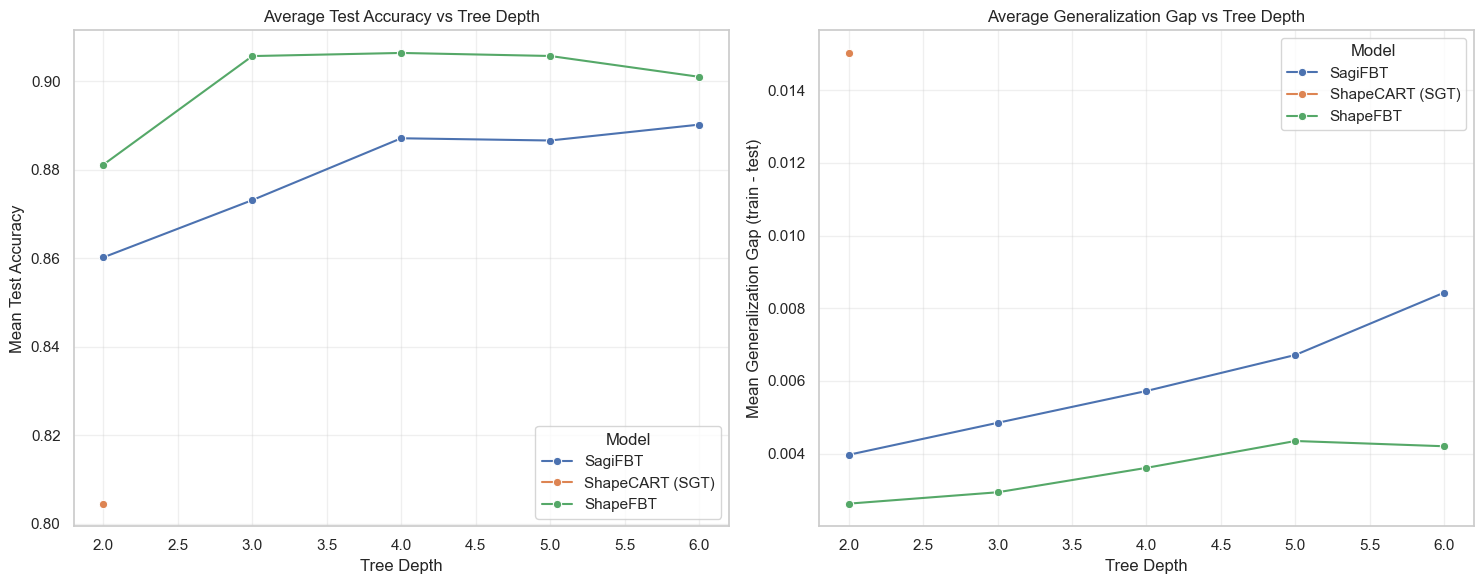

In [13]:
# Cell 8: Plot test accuracy and generalization gap vs tree depth (averaged)
fig, axes = plt.subplots(1, 2, figsize=(15, 6), sharex=False)

sns.lineplot(
    data=avg_by_depth,
    x='depth_used',
    y='test_acc_mean',
    hue='model_display',
    marker='o',
    ax=axes[0]
)
axes[0].set_title('Average Test Accuracy vs Tree Depth')
axes[0].set_xlabel('Tree Depth')
axes[0].set_ylabel('Mean Test Accuracy')
axes[0].grid(alpha=0.3)

sns.lineplot(
    data=avg_by_depth,
    x='depth_used',
    y='generalization_gap_mean',
    hue='model_display',
    marker='o',
    ax=axes[1]
)
axes[1].set_title('Average Generalization Gap vs Tree Depth')
axes[1].set_xlabel('Tree Depth')
axes[1].set_ylabel('Mean Generalization Gap (train - test)')
axes[1].grid(alpha=0.3)

# Keep one legend per subplot for easy reading
axes[0].legend(title='Model')
axes[1].legend(title='Model')

plt.tight_layout()
plt.show()